#***Objective:  Predict project Risk_Level and identify key drivers of project risk***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving Project_risk_raw_dataset.csv to Project_risk_raw_dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv("Project_risk_raw_dataset.csv")

*Lets Deal with Data Structure and mising values*

In [4]:
# Basic structure
print(df.shape)
print(df.dtypes)

# Preview data
df.head()

# Missing values
df.isnull().sum().sort_values(ascending=False).head(10)

(4000, 51)
Project_ID                          object
Project_Type                        object
Team_Size                            int64
Project_Budget_USD                 float64
Estimated_Timeline_Months            int64
Complexity_Score                   float64
Stakeholder_Count                    int64
Methodology_Used                    object
Team_Experience_Level               object
Past_Similar_Projects                int64
External_Dependencies_Count          int64
Change_Request_Frequency           float64
Project_Phase                       object
Requirement_Stability               object
Team_Turnover_Rate                 float64
Vendor_Reliability_Score           float64
Historical_Risk_Incidents            int64
Communication_Frequency            float64
Regulatory_Compliance_Level         object
Technology_Familiarity              object
Geographical_Distribution            int64
Stakeholder_Engagement_Level        object
Schedule_Pressure                  float64


,0
Tech_Environment_Stability,2619
Risk_Management_Maturity,791
Change_Control_Maturity,780
Project_Budget_USD,0
Estimated_Timeline_Months,0
Complexity_Score,0
Stakeholder_Count,0
Methodology_Used,0
Team_Experience_Level,0
Past_Similar_Projects,0


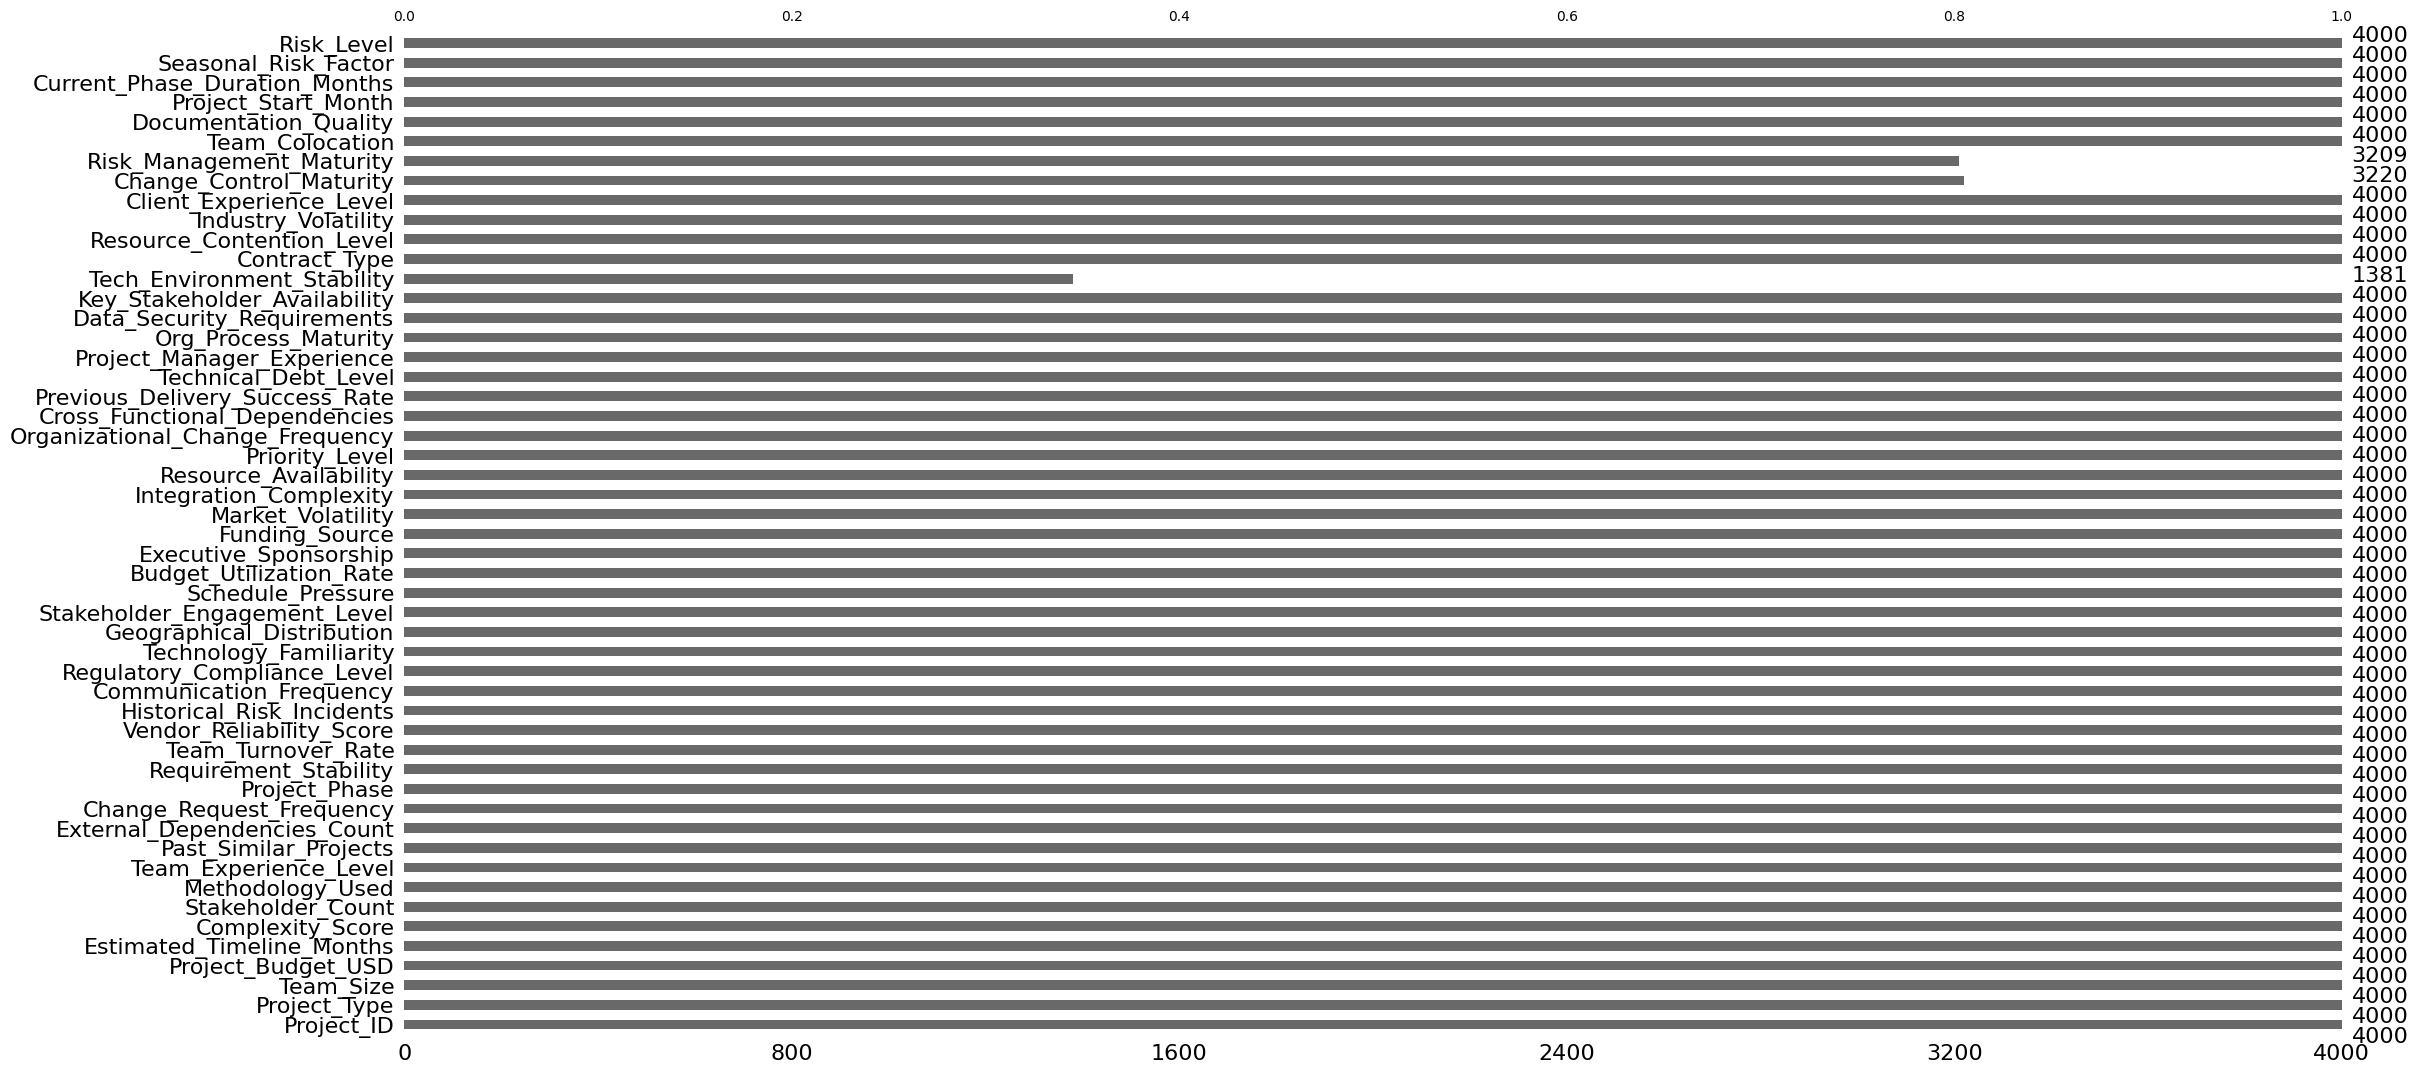

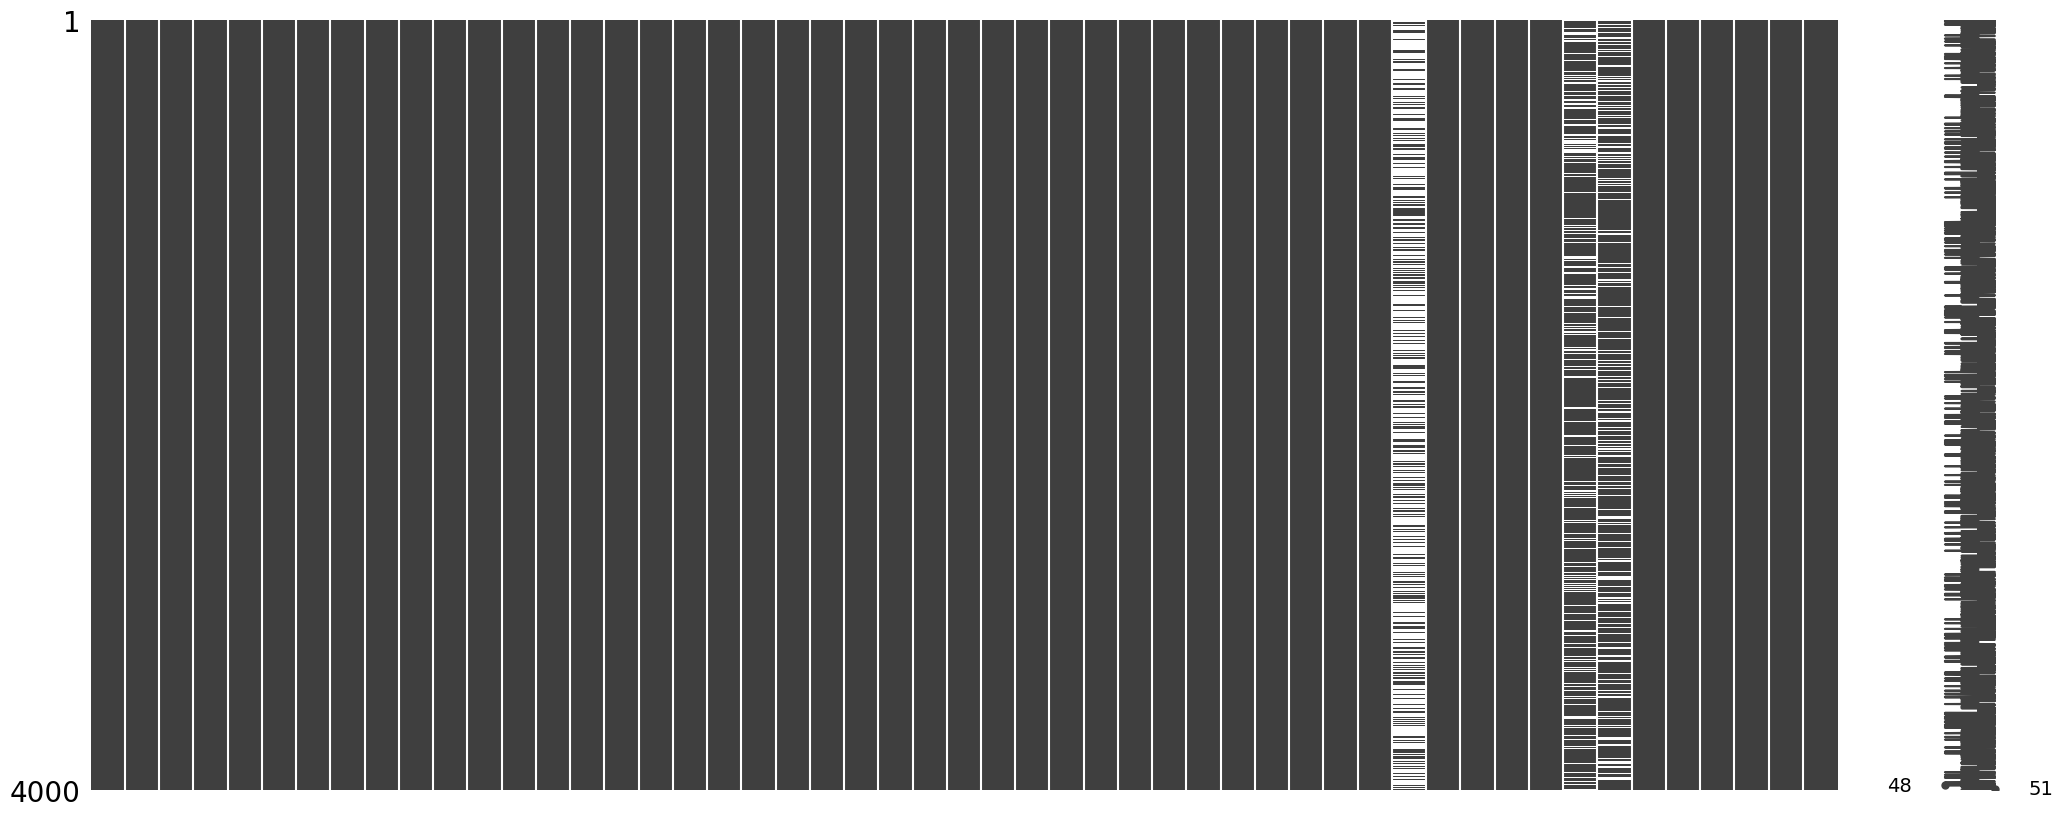

In [5]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(df)
plt.show()

msno.matrix(df)
plt.show()

 ***Complete Data Preprocessing Pipeline:*** Handling Missing Values, Encoding Categorical Variables, and Preparing Data for Machine Learning. This comprehensive preprocessing pipeline cleans the dataset by removing irrelevant identifier columns, imputing missing values (mode for categorical, median for numerical), encoding the target variable using label encoding, and converting categorical features to binary dummy variables using one-hot encoding.

In [6]:
# Drop irrelevant column
df = df.drop(columns=['Project_ID'])

# Handle missing values
# Categorical
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numeric
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Risk_Level'] = le.fit_transform(df['Risk_Level'])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

*Separates the dataset into independent variables (features) and the dependent variable (target). X contains all columns except 'Risk_Level' which will be used as input features for the model, while y contains only the 'Risk_Level' column which is what the model will learn to predict.*

In [30]:
X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

*Divides the dataset into training (80%) and testing (20%) subsets. The stratify=y parameter ensures that the proportion of each risk level class is preserved in both training and testing sets, which is crucial for imbalanced classification problems. random_state=42 makes the split reproducible.*

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

*Standardizes numerical features by removing the mean and scaling to unit variance. This ensures all features contribute equally to the model, which is especially important for algorithms sensitive to feature magnitudes like SVM, KNN, and neural networks. The scaler is fitted on training data only, then transforms both training and test sets to prevent data leakage.*

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*Trains a Logistic Regression classifier on the scaled training data to predict risk levels. The model learns patterns from the training features and corresponding target values, then generates predictions on the test data. max_iter=2000 increases the number of iterations allowed for the algorithm to converge, preventing convergence warnings.*

In [10]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

*Trains a Random Forest ensemble model consisting of 200 decision trees on the training data. Unlike Logistic Regression, Random Forest is a tree-based model that does not require feature scaling, so the original unscaled features (X_train, X_test) are used. The model aggregates predictions from all trees to produce a final classification result.*

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

*Trains an XGBoost (Extreme Gradient Boosting) model, which is an advanced ensemble method that builds trees sequentially, with each new tree correcting errors made by previous trees. XGBoost is known for high performance and handling complex patterns. Like Random Forest, it is tree-based and does not require feature scaling.*

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

*Defines a reusable evaluation function that calculates accuracy, displays a detailed classification report (precision, recall, F1-score for each class), and visualizes a heatmap of the confusion matrix. The function is then called to evaluate all three trained models (Logistic Regression, Random Forest, and XGBoost) side by side.*


Logistic Regression Accuracy: 0.7325
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       153
           1       0.62      0.70      0.66       207
           2       0.82      0.78      0.80       161
           3       0.74      0.75      0.74       279

    accuracy                           0.73       800
   macro avg       0.75      0.73      0.74       800
weighted avg       0.74      0.73      0.73       800



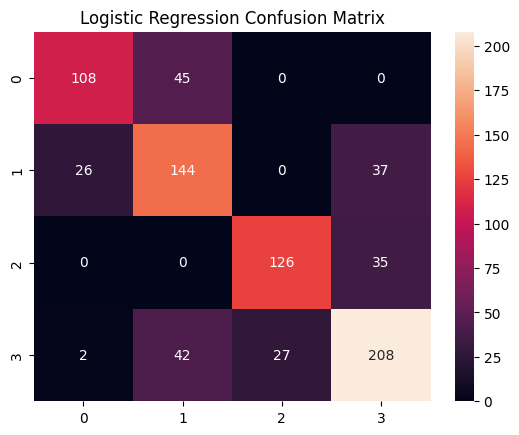


Random Forest Accuracy: 0.5025
              precision    recall  f1-score   support

           0       0.67      0.49      0.57       153
           1       0.40      0.24      0.30       207
           2       0.70      0.34      0.46       161
           3       0.46      0.80      0.58       279

    accuracy                           0.50       800
   macro avg       0.56      0.47      0.48       800
weighted avg       0.53      0.50      0.48       800



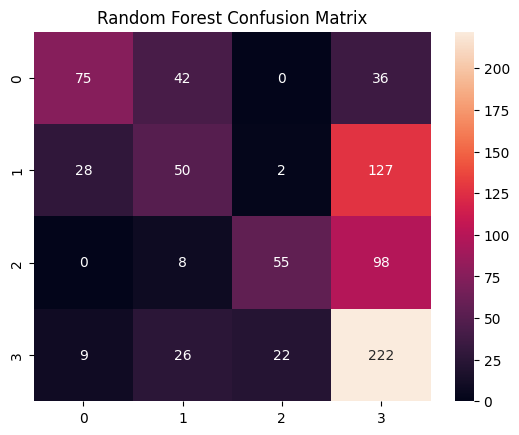


XGBoost Accuracy: 0.5725
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       153
           1       0.46      0.43      0.44       207
           2       0.73      0.59      0.65       161
           3       0.54      0.71      0.61       279

    accuracy                           0.57       800
   macro avg       0.60      0.56      0.57       800
weighted avg       0.58      0.57      0.57       800



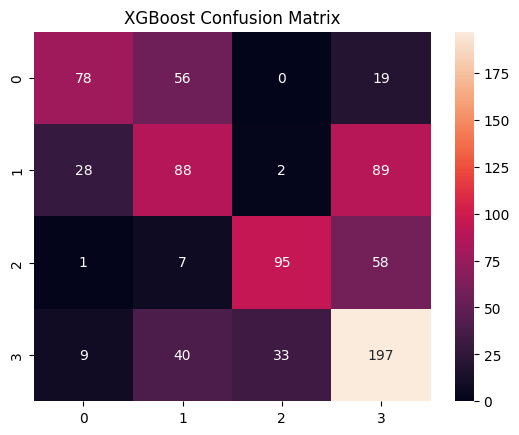

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name} Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

*Extracts and visualizes the feature importance scores from the trained XGBoost model, showing which features had the strongest influence on predicting risk levels. Features with higher importance values contributed more to decision-making within the model. This helps with model interpretation, feature selection, and understanding what drives predictions.*

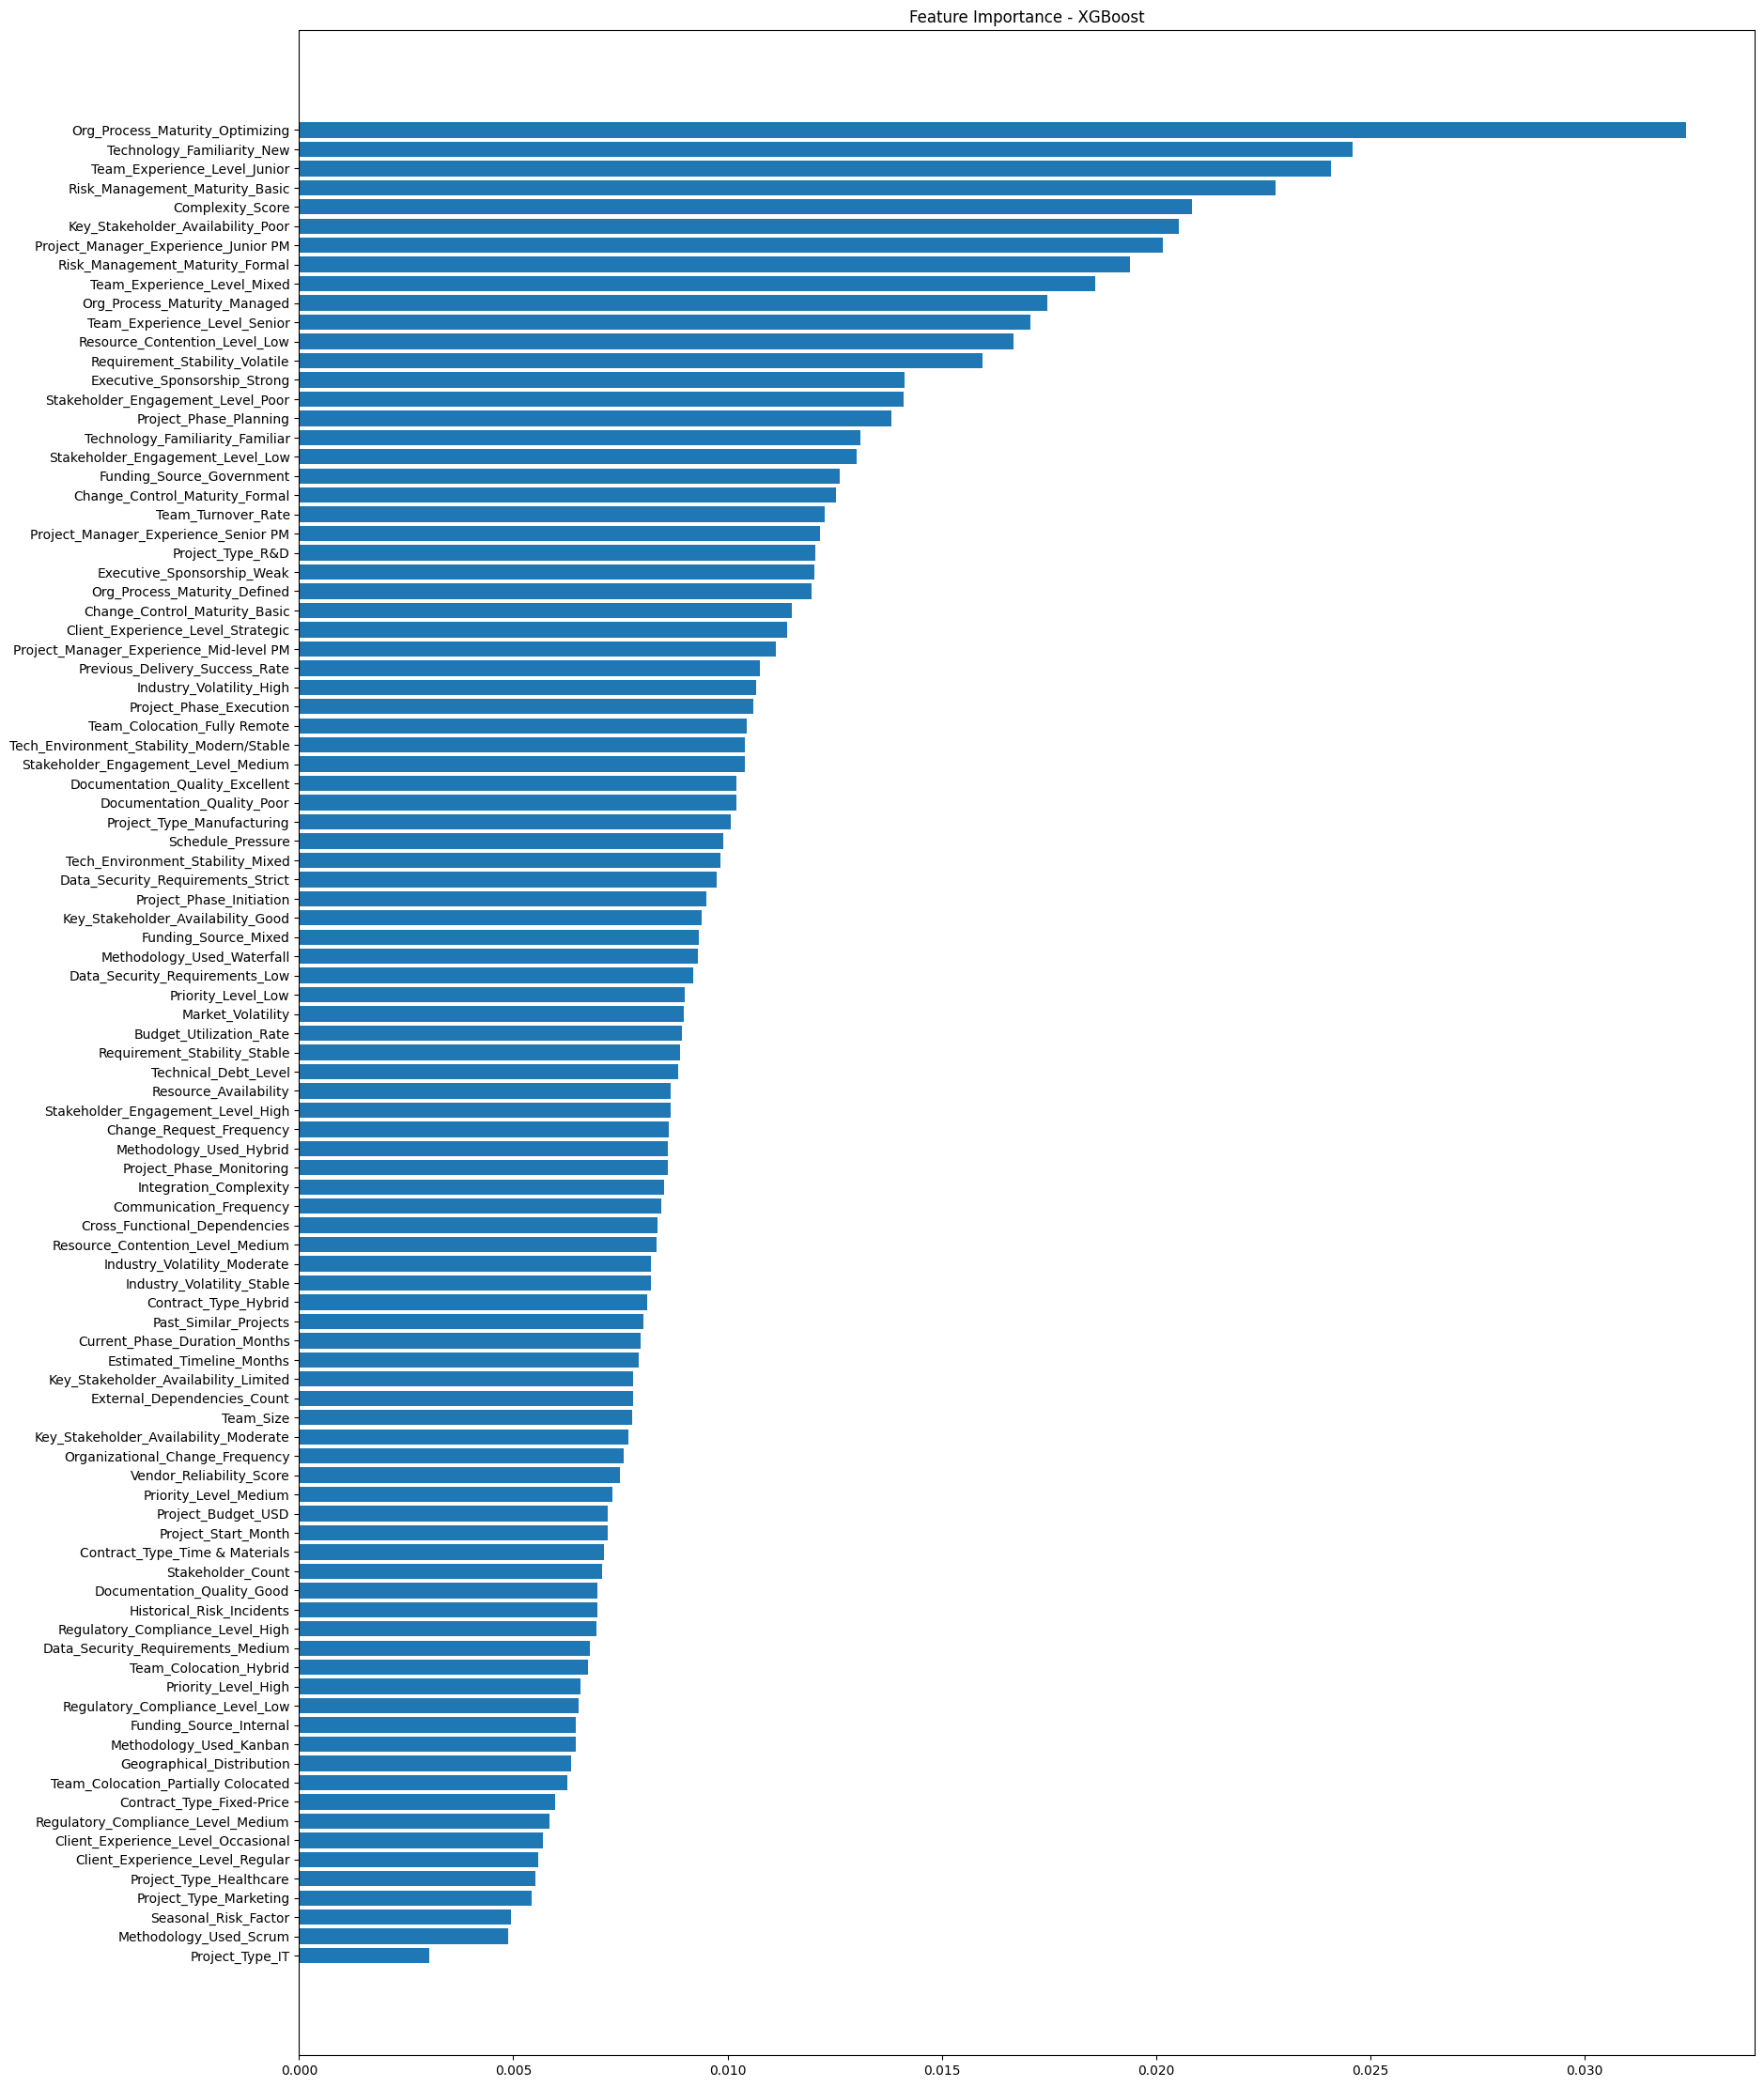

In [14]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(20,28))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.show()

*Top 10 most important feature on project risk level*

In [15]:
# Top 10 features
importance_df.head(10)

,Feature,Importance
65,Org_Process_Maturity_Optimizing,0.032351
47,Technology_Familiarity_New,0.024585
34,Team_Experience_Level_Junior,0.024073
88,Risk_Management_Maturity_Basic,0.022783
3,Complexity_Score,0.020826
72,Key_Stakeholder_Availability_Poor,0.020522
60,Project_Manager_Experience_Junior PM,0.020148
89,Risk_Management_Maturity_Formal,0.019384
35,Team_Experience_Level_Mixed,0.018568
64,Org_Process_Maturity_Managed,0.017452


*Creates a horizontal bar chart specifically for the top 10 most important features, providing a clean and readable visualization of which features are most influential in predicting risk levels. This is more practical than visualizing all features when dealing with high-dimensional data.*

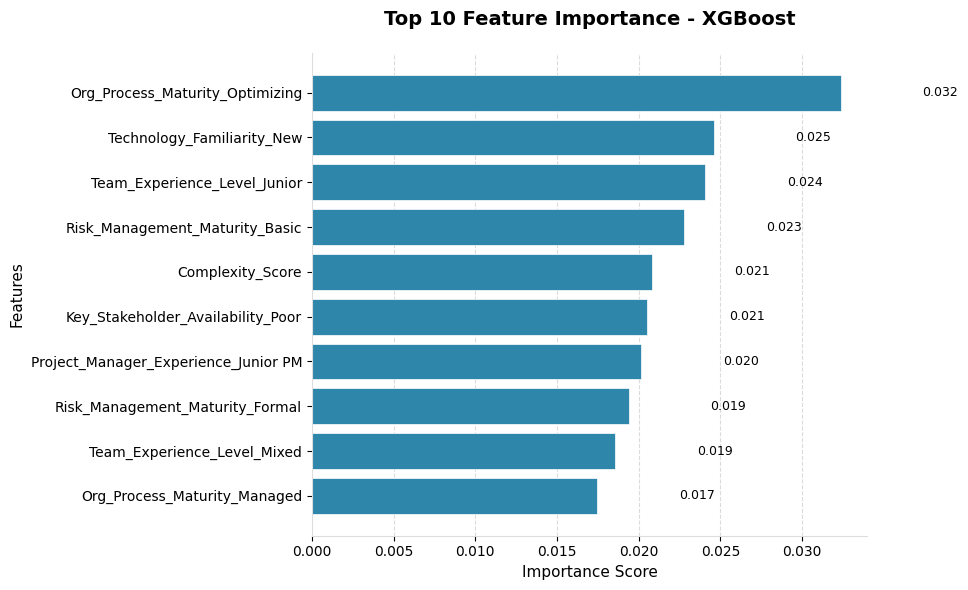

In [37]:
# Option 1: Clean Horizontal Bar Chart - Professional Report Style
top10_df = importance_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_df['Feature'], top10_df['Importance'], color='#2E86AB', edgecolor='white', linewidth=0.5)

# Customize spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# Customize grid
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#888888')
ax.set_axisbelow(True)

# Labels and title
ax.set_xlabel('Importance Score', fontsize=11, fontweight='medium')
ax.set_ylabel('Features', fontsize=11, fontweight='medium')
ax.set_title('Top 10 Feature Importance - XGBoost', fontsize=14, fontweight='bold', pad=20)

# Add value labels
for i, (bar, v) in enumerate(zip(bars, top10_df['Importance'])):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



*Exports the trained XGBoost model as a pickle file (.pkl) so it can be loaded and used later for making predictions without retraining. This is essential for deploying models to production, sharing with team members, or saving progress for future use.*

In [16]:
import joblib

joblib.dump(xgb, "project_risk_model.pkl")

['project_risk_model.pkl']

*Performs 5-fold cross-validation on the XGBoost model to evaluate its performance more reliably than a single train-test split. The dataset is split into 5 groups (folds), and the model is trained and validated 5 times, each time using a different fold as the validation set. This provides a more stable estimate of how the model will perform on unseen data.*

In [17]:
# Cross-validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5)
print("CV Score:", scores.mean())

CV Score: 0.5712499999999999


In [18]:
!pip install shap

In [19]:
X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

*Initializes and trains an XGBoost (Extreme Gradient Boosting) classifier on the training data. XGBoost is an advanced ensemble method that builds decision trees sequentially, with each new tree correcting errors made by previous trees. It is known for high performance, handling complex patterns, and being robust to outliers.*

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

*Creates a SHAP explainer specifically optimized for tree-based models to calculate SHAP values for test data. These values quantify the contribution of each feature to every individual prediction, showing whether a feature pushed the prediction toward a higher or lower risk level.*

In [21]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

*Creates a SHAP summary plot that visualizes feature importance and impact direction for all test samples simultaneously. This plot shows which features are most influential for predicting risk levels, how they affect predictions (positive or negative impact), and the distribution of their effects across all predictions.*

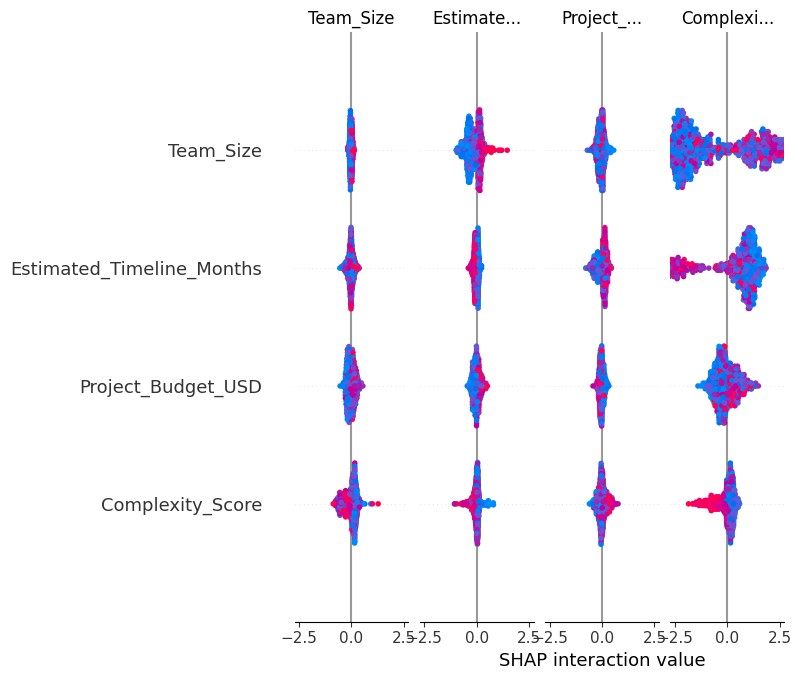

In [22]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [42]:
# Check these metrics separately to assess model quality
print(f"Model accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Cross-validation score: {scores.mean()}")
print(f"Training accuracy: {xgb.score(X_train, y_train)}")

Model accuracy: 0.5725
Cross-validation score: 0.5712499999999999
Training accuracy: 1.0


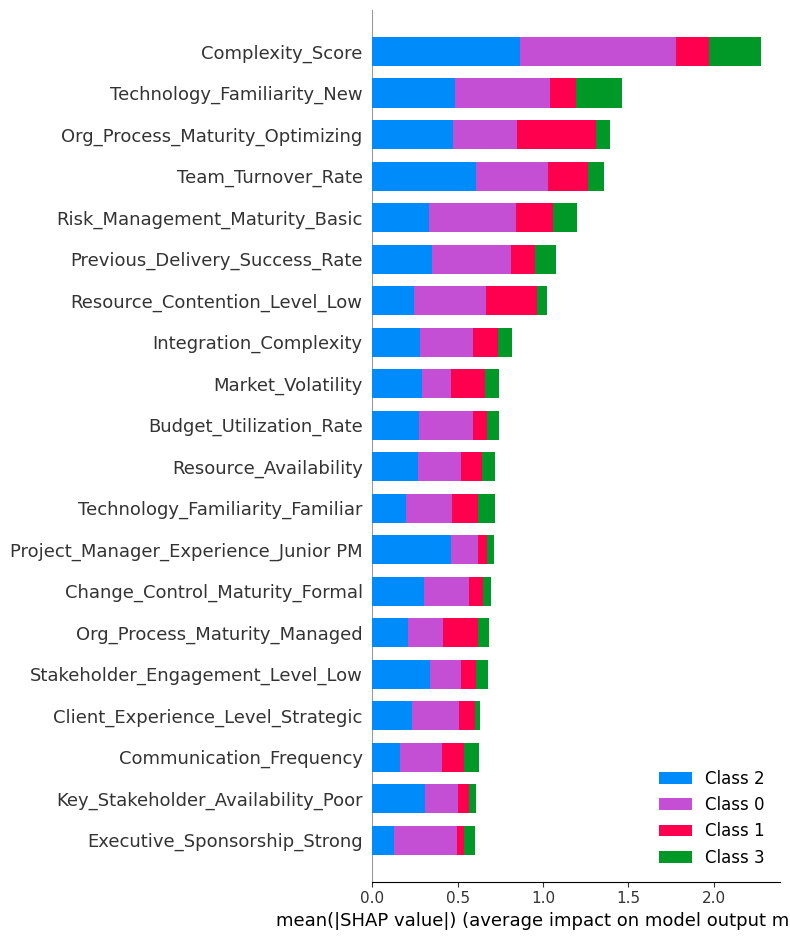

In [48]:
# Bar plot - simplest, most professional shape
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns)

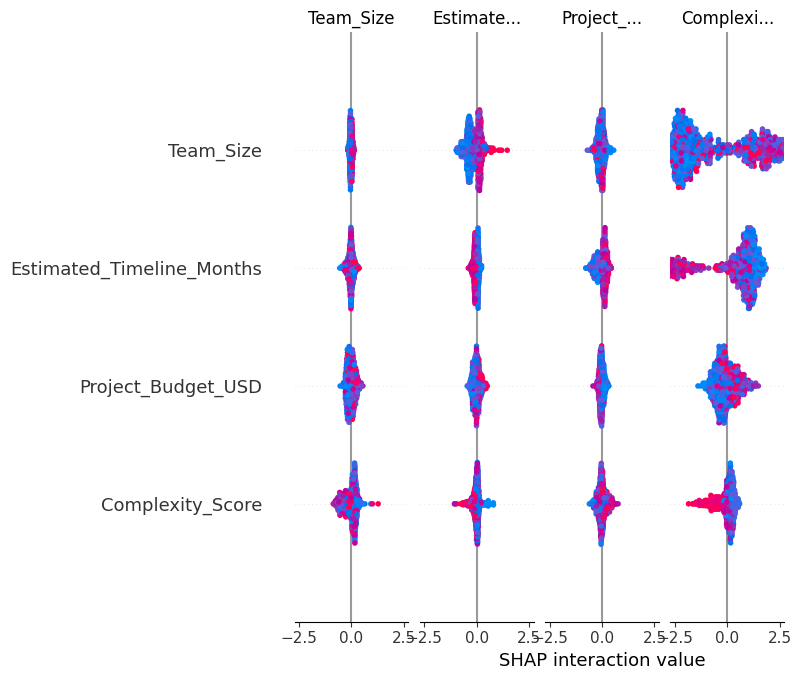

In [44]:
# This is what you currently have
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

***Feature importance varies across models due to differences in how they capture relationships in the data. Logistic Regression assumes linear relationships and evaluates independent feature effects, while XGBoost captures non-linear interactions and complex dependencies.To address this, SHAP analysis was used to provide a unified and consistent interpretation of feature impact, confirming that process maturity, team experience, stakeholder engagement, and technology familiarity are the most critical drivers of project risk.***

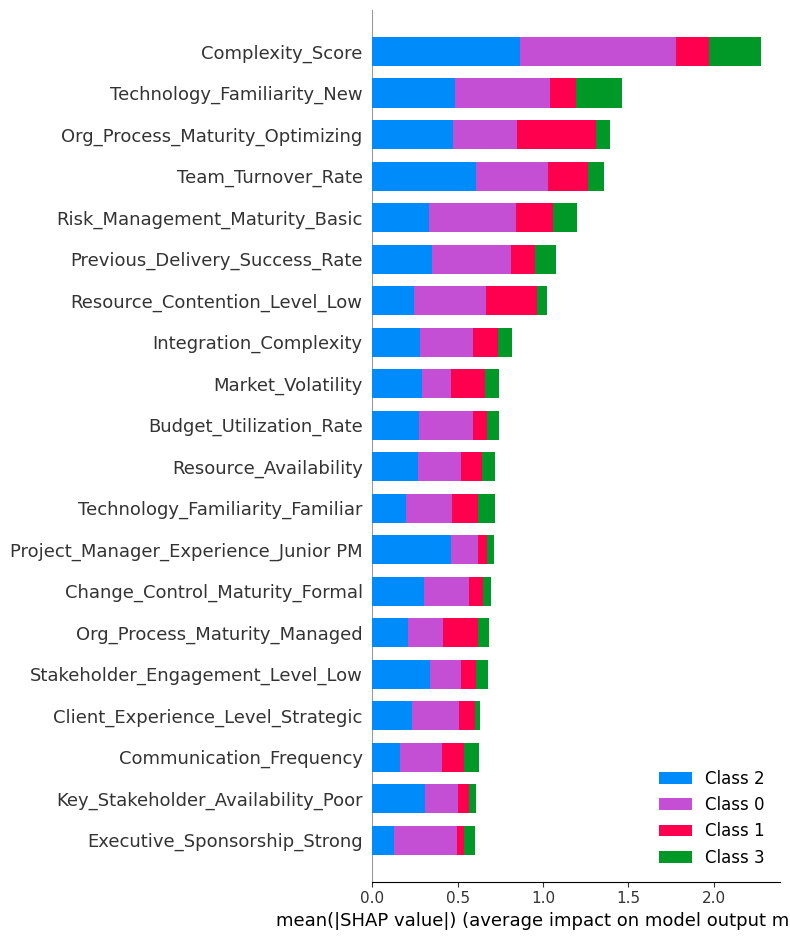

In [24]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

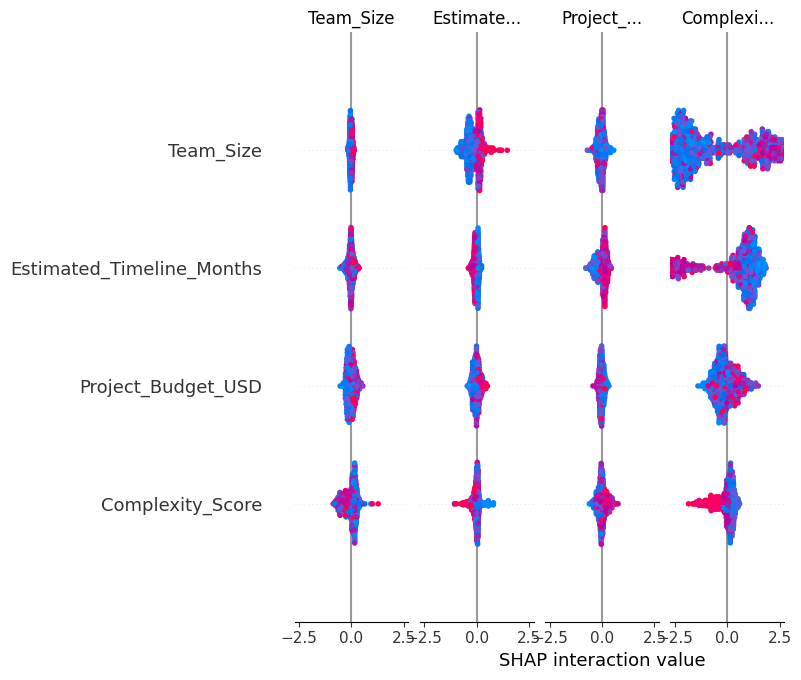

In [25]:
shap.summary_plot(shap_values, X_test)

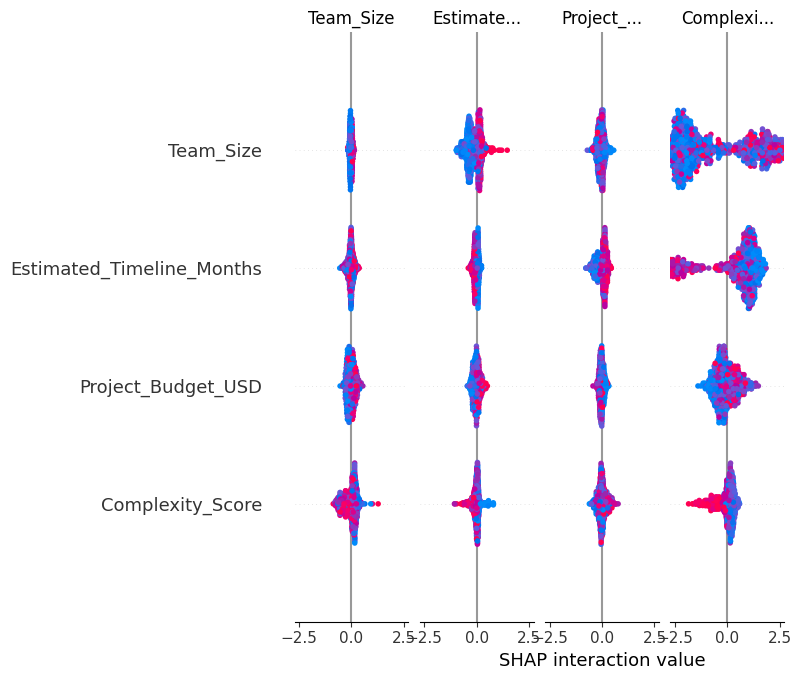

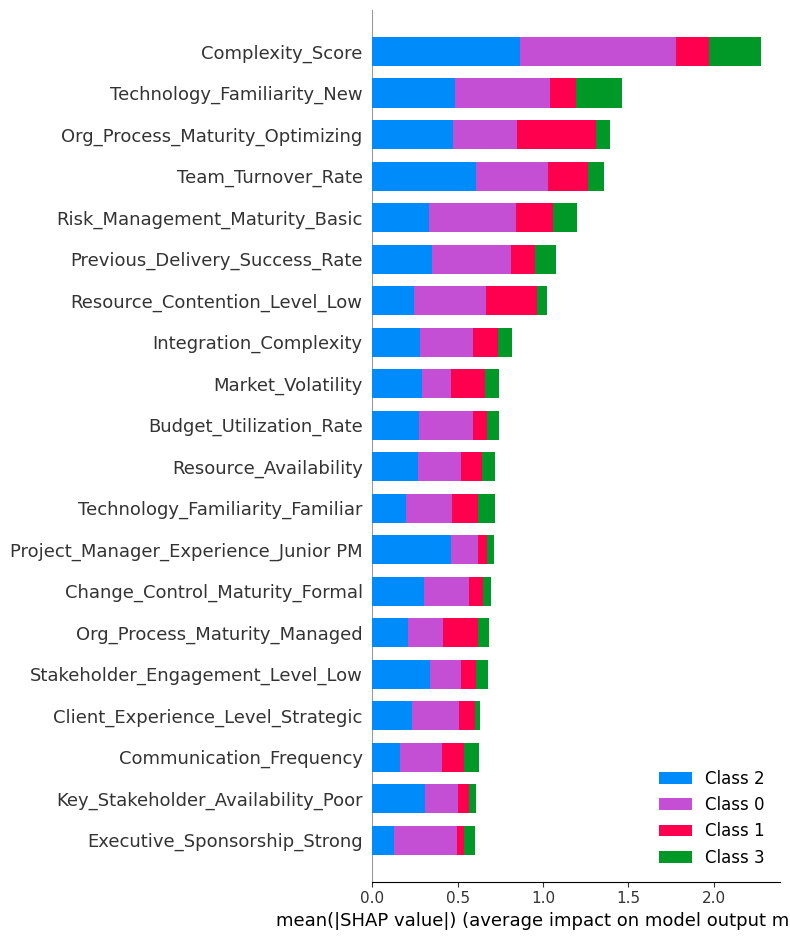

In [26]:
shap.summary_plot(shap_values, X_test)           # detailed
shap.summary_plot(shap_values, X_test, plot_type="bar")  # summary

**Project Risk Prediction using Machine Learning**

Overview
This project develops a machine learning solution to predict project risk levels based on key project attributes such as team experience, stakeholder engagement, process maturity, and technology familiarity. The goal is to help project managers proactively identify high-risk projects and take corrective actions early.


**Business Objective**
To predict project risk levels before issues occur and provide data-driven insights for better decision-making.
Dataset
The dataset contains approximately 4000 project records with over 50 features including project budget, team size, stakeholder engagement, technology familiarity, and process maturity.


**Methodology**
This project follows the IBM Data Science Methodology including business understanding, data understanding, data preparation, modeling, evaluation, and deployment.


**Data Preparation**
Missing values were handled using mode for categorical variables and median for numerical variables. Irrelevant columns were removed, and categorical features were encoded using one-hot encoding.


**Models Used**
Logistic Regression, Random Forest, and XGBoost were used to build predictive models.


**Model Evaluation**
Models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Logistic Regression achieved around 70% accuracy.
Feature Importance & Explainability
Logistic Regression provided directional insights, while XGBoost identified key drivers. SHAP analysis was used to explain model predictions.


**Key Insights**
- Process maturity is the strongest driver of project risk
- Team experience significantly impacts outcomes
- Stakeholder engagement is critical
- Technology unfamiliarity increases risk
- Project budget is not a major driver


**Business Recommendations**
Improve process maturity, assign experienced teams, enhance stakeholder engagement, and provide training for new technologies.
Future Work
Future improvements include hyperparameter tuning, cross-validation, and building an interactive dashboard using Streamlit.


**Technologies Used**
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost, SHAP





Author
Nematullah Amiri
PMP Certified | Data Science Enthusiast
